# Indian Liver Patient Dataset — Exploration and Cleaning

This notebook loads, audits, visualizes, and cleans the official UCI ILPD dataset before model training.

**Prediction target:** `liver_disease` (`0` = No liver disease, `1` = Liver disease)  
**Source:** UCI Machine Learning Repository, ILPD (Dataset ID 225)  
**License:** Creative Commons Attribution 4.0 International (CC BY 4.0)  
**DOI:** https://doi.org/10.24432/C5D02C

The dataset is preserved unchanged in `data/raw`. Cleaning is performed on an independent copy and saved to `data/processed/liver_disease_clean.csv`.

## 1. Environment Setup and Project Paths

This cell imports the libraries required for data handling and visualization, locates the project root, and defines the raw-data, processed-data, and report-figure paths.

Keeping these paths centralized makes the notebook reproducible and ensures that the exploration stage reads from the raw-data folder while writing cleaned outputs to a separate processed-data folder.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configure chart appearance and table display
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Locate the project root from either the project or notebooks folder
current_folder = Path.cwd()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "Indian Liver Patient Dataset (ILPD).csv"
)
processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "liver_disease_clean.csv"
)
figures_folder = project_root / "reports" / "figures"

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Dataset path:", raw_data_path)
print("File exists:", raw_data_path.exists())

if not raw_data_path.exists():
    raise FileNotFoundError(
        "Place Indian Liver Patient Dataset (ILPD).csv inside data/raw."
    )

Dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\raw\Indian Liver Patient Dataset (ILPD).csv
File exists: True


## 2. Loading the Raw ILPD Dataset

The Indian Liver Patient Dataset CSV does not contain a header row, so the expected feature names are supplied explicitly when the file is loaded.

This step establishes the original dataset structure before any cleaning is performed. The raw copy is preserved so that later transformations remain traceable and reproducible.


In [2]:
# Define names because the official CSV does not contain a header row
column_names = [
    "age",
    "gender",
    "total_bilirubin",
    "direct_bilirubin",
    "alkaline_phosphatase",
    "alanine_aminotransferase",
    "aspartate_aminotransferase",
    "total_proteins",
    "albumin",
    "albumin_globulin_ratio",
    "selector",
]

liver_raw = pd.read_csv(
    raw_data_path,
    header=None,
    names=column_names,
)

print("Dataset shape:", liver_raw.shape)
print("Column names:")
print(liver_raw.columns.tolist())
print("\nData types:")
print(liver_raw.dtypes)
display(liver_raw.head())

Dataset shape: (583, 11)
Column names:
['age', 'gender', 'total_bilirubin', 'direct_bilirubin', 'alkaline_phosphatase', 'alanine_aminotransferase', 'aspartate_aminotransferase', 'total_proteins', 'albumin', 'albumin_globulin_ratio', 'selector']

Data types:
age                             int64
gender                            str
total_bilirubin               float64
direct_bilirubin              float64
alkaline_phosphatase            int64
alanine_aminotransferase        int64
aspartate_aminotransferase      int64
total_proteins                float64
albumin                       float64
albumin_globulin_ratio        float64
selector                        int64
dtype: object


,age,gender,total_bilirubin,direct_bilirubin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,total_proteins,albumin,albumin_globulin_ratio,selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 3. Initial Data-Quality Audit

The notebook checks the main quality characteristics of the raw dataset:

- Missing values.
- Number of unique values.
- Duplicate rows.
- Original target labels.

This audit provides a baseline before cleaning and helps identify issues that may affect preprocessing or model evaluation.


In [3]:
# Audit missing values, unique values, duplicates, and target labels
quality_summary = pd.DataFrame(
    {
        "Data Type": liver_raw.dtypes.astype(str),
        "Missing Values": liver_raw.isnull().sum(),
        "Missing Percentage": liver_raw.isnull().mean().mul(100).round(2),
        "Unique Values": liver_raw.nunique(dropna=True),
    }
)

print("Raw data quality summary:")
display(quality_summary.sort_values("Missing Values", ascending=False))
print("Duplicated rows:", int(liver_raw.duplicated().sum()))
print(
    "Duplicated feature profiles:",
    int(liver_raw.drop(columns=["selector"]).duplicated().sum()),
)
print("\nTarget distribution:")
print(liver_raw["selector"].value_counts(dropna=False).sort_index())
print("\nGender distribution:")
print(liver_raw["gender"].value_counts(dropna=False))

Raw data quality summary:


,Data Type,Missing Values,Missing Percentage,Unique Values
albumin_globulin_ratio,float64,4,0.69,69
gender,str,0,0.00,2
age,int64,0,0.00,72
total_bilirubin,float64,0,0.00,113
direct_bilirubin,float64,0,0.00,80
alanine_aminotransferase,int64,0,0.00,152
alkaline_phosphatase,int64,0,0.00,263
aspartate_aminotransferase,int64,0,0.00,177
total_proteins,float64,0,0.00,58
albumin,float64,0,0.00,40


Duplicated rows: 13
Duplicated feature profiles: 13

Target distribution:
selector
1    416
2    167
Name: count, dtype: int64

Gender distribution:
gender
Male      441
Female    142
Name: count, dtype: int64


## 4. Schema and Value Validation

The observed columns and selected documented values are compared with the expected ILPD structure.

Validation at this stage helps detect accidental column shifts, unexpected category labels, or incompatible source files before the dataset enters the modeling workflow.


In [4]:
# Validate the dataset schema and documented values
expected_columns = set(column_names)
observed_columns = set(liver_raw.columns)

if observed_columns != expected_columns:
    raise ValueError(
        f"Unexpected columns: {sorted(observed_columns.symmetric_difference(expected_columns))}"
    )

invalid_gender_values = sorted(
    set(liver_raw["gender"].dropna().astype(str).str.strip())
    - {"Male", "Female"}
)
invalid_target_values = sorted(
    set(liver_raw["selector"].dropna()) - {1, 2}
)

print("Invalid gender values:", invalid_gender_values)
print("Invalid target values:", invalid_target_values)

if invalid_gender_values or invalid_target_values:
    raise ValueError("Unexpected categorical values were found.")

Invalid gender values: []
Invalid target values: []


## Cleaning decisions

- Standardize column names and gender labels.
- Map the official selector value `1` to liver disease (`1`) and `2` to no liver disease (`0`).
- Remove only exact duplicated records to prevent the same patient profile from crossing future data splits.
- Preserve the four missing A/G-ratio values for imputation inside the future machine-learning pipeline.
- Preserve extreme laboratory measurements because they can represent clinically important disease cases; no medical outlier is removed without external clinical justification.

## 5. Cleaning and Binary Target Construction

A separate working copy is cleaned without modifying the original raw dataset.

The main operations include standardizing text fields, converting appropriate columns to numeric form, normalizing the gender field, and mapping the original dataset class label into a binary target suitable for supervised classification.

Missing laboratory values are preserved so they can later be imputed inside the machine-learning pipeline rather than before the data split.


In [5]:
# Create and clean an independent copy without modifying the raw dataset
liver_clean = liver_raw.copy()

liver_clean["gender"] = (
    liver_clean["gender"]
    .astype("string")
    .str.strip()
    .str.lower()
)

target_mapping = {
    1: 1,
    2: 0,
}
liver_clean["liver_disease"] = liver_clean["selector"].map(target_mapping)

if liver_clean["liver_disease"].isnull().any():
    unexpected_targets = liver_clean.loc[
        liver_clean["liver_disease"].isnull(), "selector"
    ].unique()
    raise ValueError(f"Unexpected target labels: {unexpected_targets}")

liver_clean["liver_disease"] = liver_clean["liver_disease"].astype("int8")
liver_clean = liver_clean.drop(columns=["selector"])

rows_before_deduplication = len(liver_clean)
liver_clean = liver_clean.drop_duplicates().reset_index(drop=True)
removed_duplicates = rows_before_deduplication - len(liver_clean)

print("Original shape:", liver_raw.shape)
print("Cleaned shape:", liver_clean.shape)
print("Removed exact duplicates:", removed_duplicates)
print("Remaining duplicated rows:", int(liver_clean.duplicated().sum()))
print("Remaining missing values:", int(liver_clean.isnull().sum().sum()))
display(liver_clean.head())

Original shape: (583, 11)
Cleaned shape: (570, 11)
Removed exact duplicates: 13
Remaining duplicated rows: 0
Remaining missing values: 4


,age,gender,total_bilirubin,direct_bilirubin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,total_proteins,albumin,albumin_globulin_ratio,liver_disease
0,65,female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 6. Numerical Feature Review

Summary statistics are generated for the numerical variables.

Extreme laboratory measurements are not automatically removed because unusually high or low values may represent genuine disease cases rather than data-entry errors. This distinction is important in healthcare datasets, where clinically abnormal values may contain useful predictive information.


In [6]:
# Summarize numerical variables without treating valid extremes as errors
numerical_features = liver_clean.select_dtypes(include=["number"]).columns.tolist()
numerical_features.remove("liver_disease")

numerical_summary = liver_clean[numerical_features].describe().T
numerical_summary["Missing Values"] = liver_clean[numerical_features].isnull().sum()
numerical_summary["Zero Values"] = (liver_clean[numerical_features] == 0).sum()

display(
    numerical_summary[
        ["min", "max", "mean", "50%", "std", "Missing Values", "Zero Values"]
    ].round(3)
)

# Flag impossible values only; high laboratory values are retained
invalid_ranges = {
    "age": liver_clean["age"].lt(0),
    "total_bilirubin": liver_clean["total_bilirubin"].lt(0),
    "direct_bilirubin": liver_clean["direct_bilirubin"].lt(0),
    "alkaline_phosphatase": liver_clean["alkaline_phosphatase"].lt(0),
    "alanine_aminotransferase": liver_clean["alanine_aminotransferase"].lt(0),
    "aspartate_aminotransferase": liver_clean["aspartate_aminotransferase"].lt(0),
    "total_proteins": liver_clean["total_proteins"].lt(0),
    "albumin": liver_clean["albumin"].lt(0),
    "albumin_globulin_ratio": liver_clean["albumin_globulin_ratio"].lt(0),
}

invalid_range_counts = {
    feature: int(mask.fillna(False).sum())
    for feature, mask in invalid_ranges.items()
}
print("Invalid negative-value counts:", invalid_range_counts)

,min,max,mean,50%,std,Missing Values,Zero Values
age,4.0,90.0,44.849,45.00,16.242,0,0
total_bilirubin,0.4,75.0,3.322,1.00,6.268,0,0
direct_bilirubin,0.1,19.7,1.498,0.30,2.833,0,0
alkaline_phosphatase,63.0,2110.0,291.751,208.00,245.292,0,0
alanine_aminotransferase,10.0,2000.0,79.728,35.00,181.472,0,0
aspartate_aminotransferase,10.0,4929.0,109.381,41.00,290.881,0,0
total_proteins,2.7,9.6,6.496,6.60,1.088,0,0
albumin,0.9,5.5,3.149,3.10,0.797,0,0
albumin_globulin_ratio,0.3,2.8,0.948,0.95,0.320,4,0


Invalid negative-value counts: {'age': 0, 'total_bilirubin': 0, 'direct_bilirubin': 0, 'alkaline_phosphatase': 0, 'alanine_aminotransferase': 0, 'aspartate_aminotransferase': 0, 'total_proteins': 0, 'albumin': 0, 'albumin_globulin_ratio': 0}


## 7. Target and Gender Distribution

This step examines the overall liver-disease class distribution and how the target is distributed across gender categories.

The purpose is descriptive: it helps identify class imbalance and sample-composition differences that should be considered when interpreting model performance.


,Count,Percentage
No liver disease,164,28.77
Liver disease,406,71.23


,No liver disease,Liver disease,Total
gender,,,
female,49,91,140
male,115,315,430
All,164,406,570


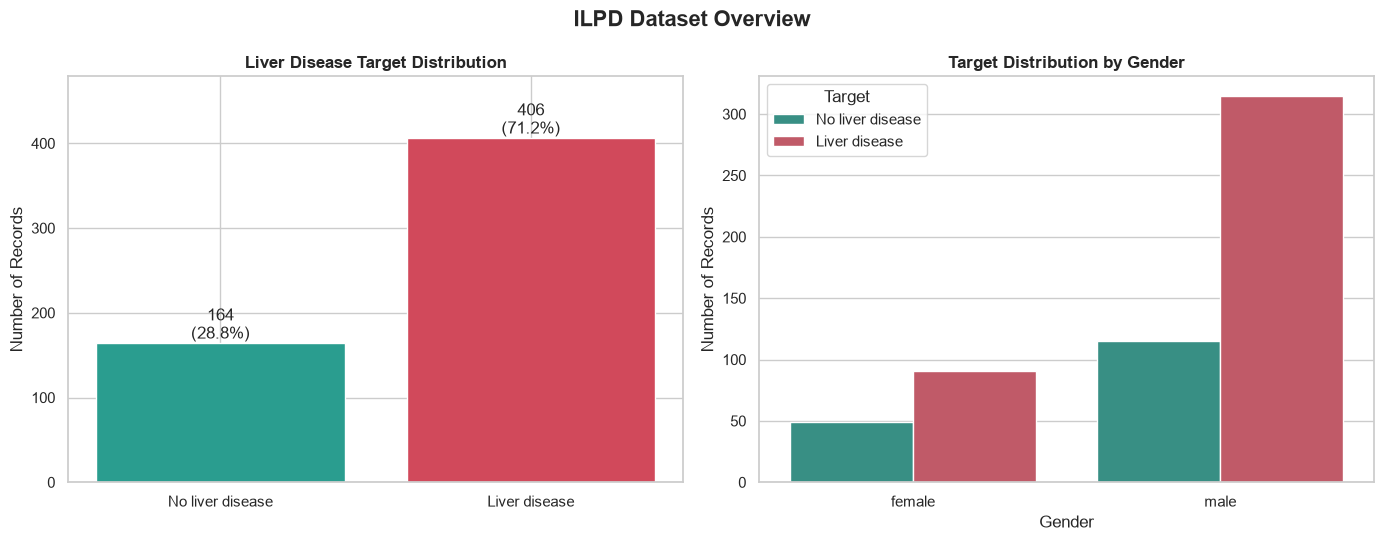

Overview figure saved: True
Overview figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\liver_dataset_overview.png


In [7]:
# Compare the target distribution overall and by gender
target_counts = liver_clean["liver_disease"].value_counts().sort_index()
target_percentages = target_counts.div(target_counts.sum()).mul(100)

gender_target_table = pd.crosstab(
    liver_clean["gender"],
    liver_clean["liver_disease"],
    margins=True,
)
gender_target_table.columns = ["No liver disease", "Liver disease", "Total"]

display(
    pd.DataFrame(
        {
            "Count": target_counts,
            "Percentage": target_percentages.round(2),
        },
        index=[0, 1],
    ).rename(index={0: "No liver disease", 1: "Liver disease"})
)
display(gender_target_table)

figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))

bars = axes[0].bar(
    ["No liver disease", "Liver disease"],
    target_counts.values,
    color=["#2A9D8F", "#D1495B"],
)
for bar, count, percentage in zip(
    bars, target_counts.values, target_percentages.values
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
    )
axes[0].set_title("Liver Disease Target Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Records")
axes[0].set_ylim(0, target_counts.max() * 1.18)

sns.countplot(
    data=liver_clean,
    x="gender",
    hue="liver_disease",
    hue_order=[0, 1],
    palette=["#2A9D8F", "#D1495B"],
    ax=axes[1],
)
axes[1].set_title("Target Distribution by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Records")
axes[1].legend(title="Target", labels=["No liver disease", "Liver disease"])

figure.suptitle("ILPD Dataset Overview", fontsize=16, fontweight="bold")
plt.tight_layout()

overview_figure_path = figures_folder / "liver_dataset_overview.png"
plt.savefig(overview_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Overview figure saved:", overview_figure_path.exists())
print("Overview figure path:", overview_figure_path)

## 8. Laboratory Feature Distributions

Several highly skewed laboratory measurements are visualized using logarithmic x-axes.

The logarithmic scale improves readability when a small number of observations are much larger than the majority. These plots help compare the distributions of important liver-related measurements across the target classes without deleting valid extreme observations.


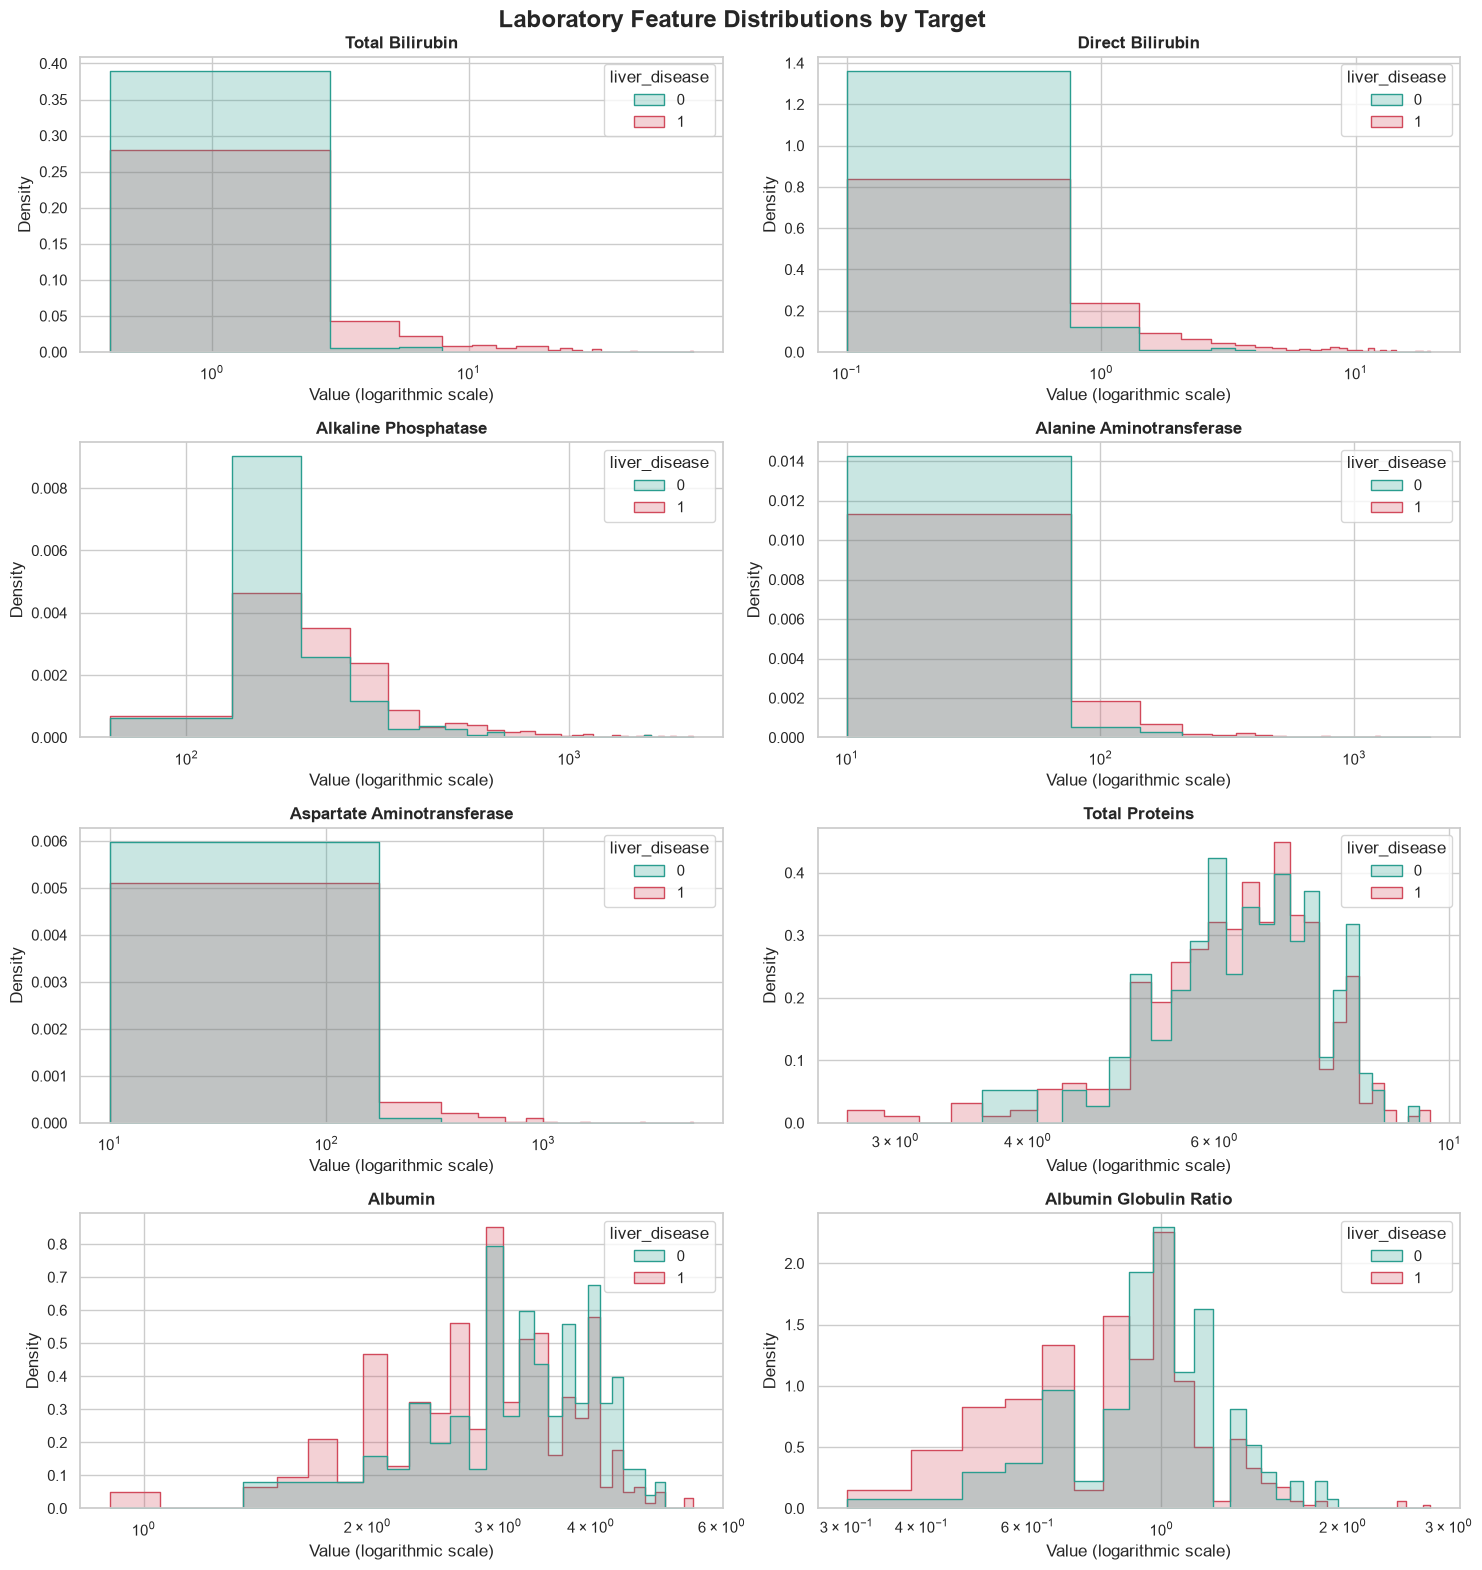

Distribution figure saved: True


In [8]:
# Visualize skewed laboratory measurements using logarithmic x-axes
laboratory_features = [
    "total_bilirubin",
    "direct_bilirubin",
    "alkaline_phosphatase",
    "alanine_aminotransferase",
    "aspartate_aminotransferase",
    "total_proteins",
    "albumin",
    "albumin_globulin_ratio",
]

figure, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for axis, feature in zip(axes, laboratory_features):
    sns.histplot(
        data=liver_clean,
        x=feature,
        hue="liver_disease",
        hue_order=[0, 1],
        bins=30,
        element="step",
        stat="density",
        common_norm=False,
        palette=["#2A9D8F", "#D1495B"],
        ax=axis,
    )
    axis.set_xscale("log")
    axis.set_title(feature.replace("_", " ").title(), fontweight="bold")
    axis.set_xlabel("Value (logarithmic scale)")

figure.suptitle(
    "Laboratory Feature Distributions by Target",
    fontsize=17,
    fontweight="bold",
)
plt.tight_layout()

distribution_figure_path = figures_folder / "liver_feature_distributions.png"
plt.savefig(distribution_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Distribution figure saved:", distribution_figure_path.exists())

## 9. Correlation with the Binary Target

Pearson correlations are calculated between the numerical predictors and the liver-disease target.

This provides an exploratory view of linear associations, but the values should not be interpreted as causal medical relationships. A feature may still be useful to a nonlinear classifier even if its simple linear correlation is modest.


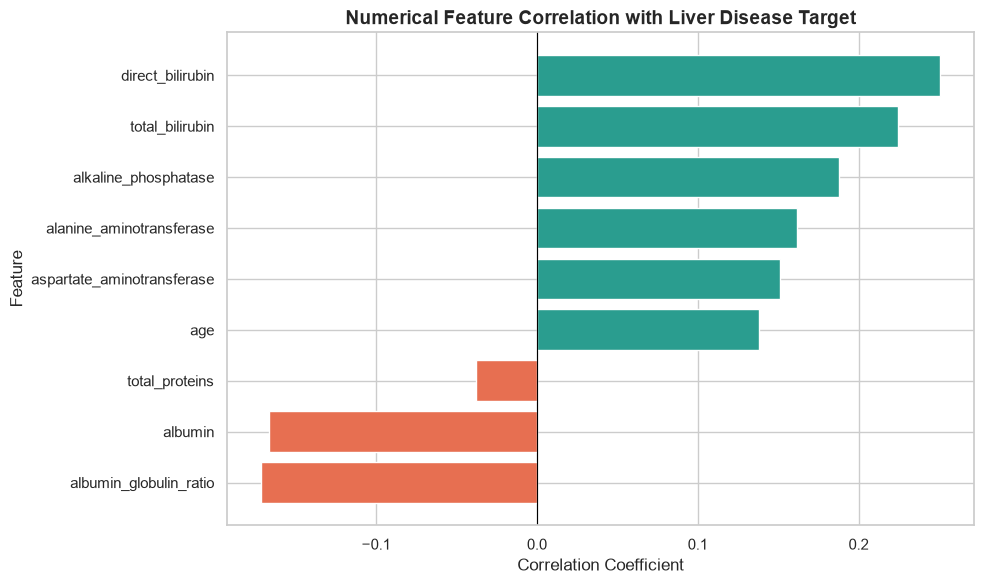

,Correlation
albumin_globulin_ratio,-0.1714
albumin,-0.1668
total_proteins,-0.0378
age,0.1381
aspartate_aminotransferase,0.1511
alanine_aminotransferase,0.1619
alkaline_phosphatase,0.1876
total_bilirubin,0.2244
direct_bilirubin,0.2507


Correlation figure saved: True


In [9]:
# Calculate numerical correlations with the binary target
correlations = (
    liver_clean[numerical_features + ["liver_disease"]]
    .corr(numeric_only=True)["liver_disease"]
    .drop("liver_disease")
    .sort_values()
)

colors = ["#E76F51" if value < 0 else "#2A9D8F" for value in correlations]

plt.figure(figsize=(10, 6))
plt.barh(correlations.index, correlations.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Numerical Feature Correlation with Liver Disease Target",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

correlation_figure_path = figures_folder / "liver_numeric_correlations.png"
plt.savefig(correlation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

display(correlations.to_frame("Correlation").round(4))
print("Correlation figure saved:", correlation_figure_path.exists())

## 10. Saving the Processed Dataset

The cleaned dataset is saved while retaining missing values.

This is intentional: missing-value imputation is performed later inside the training pipeline after the dataset has been split. Doing so prevents information from validation or test records from influencing preprocessing statistics and reduces the risk of data leakage.


In [10]:
# Save the cleaned data while preserving missing values for pipeline imputation
liver_clean.to_csv(processed_data_path, index=False)

saved_liver_data = pd.read_csv(processed_data_path)

print("Processed file saved:", processed_data_path.exists())
print("Processed file path:", processed_data_path)
print("Saved dataset shape:", saved_liver_data.shape)
print("Saved target values:", sorted(saved_liver_data["liver_disease"].unique()))
print("Remaining missing values:", int(saved_liver_data.isnull().sum().sum()))
print("Remaining duplicates:", int(saved_liver_data.duplicated().sum()))

Processed file saved: True
Processed file path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\liver_disease_clean.csv
Saved dataset shape: (570, 11)
Saved target values: [np.int64(0), np.int64(1)]
Remaining missing values: 4
Remaining duplicates: 0


## Main findings and modeling implications

- The raw file contains 583 records, 10 predictors, and one selector column.
- Selector `1` indicates a liver patient and selector `2` indicates a non-liver patient; the cleaned target uses conventional binary values.
- The positive class is the majority class, so plain accuracy and the majority baseline can be misleading. Future evaluation should emphasize balanced accuracy, precision, recall, F1, ROC-AUC, and PR-AUC.
- Four A/G-ratio values are missing and must be imputed inside each training pipeline after splitting.
- Thirteen exact duplicate records are removed before splitting to reduce leakage risk.
- Several laboratory variables are strongly right-skewed. Robust preprocessing or log transformation should be evaluated inside the training workflow.
- Sex-stratified metrics should be reported because the dataset is sex-imbalanced and the UCI documentation highlights possible gender-related bias.
- Correlation indicates association, not causation or complete model importance.
- The application must describe its output as educational screening, never as a medical diagnosis.

### Required attribution

Ramana, B., & Venkateswarlu, N. (2022). *ILPD (Indian Liver Patient Dataset)* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5D02C